# Vision Transformers in PyTorch

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 3

**Objective:** Build a PyTorch-based hybrid Convolutional Neural Network
(CNN) and Vision Transformer (ViT) for image classification, mirroring the
Keras version from the previous lab.

**Prerequisite:** run the PyTorch CNN training lab first, so that
`pytorch_cnn_classifier.pt` exists.


## 1. Import libraries and packages

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("images_dataSAT")
MODELS_DIR = Path(".")
IMG_SIZE = (64, 64)
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

assert (MODELS_DIR / "pytorch_cnn_classifier.pt").exists(), \
    "Pretrained PyTorch CNN not found -- run the PyTorch training lab first."


Using device: cpu


## 2. Load data

In [2]:
transform = transforms.Compose([transforms.ToTensor()])
full_dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=transform)

n_total = len(full_dataset)
n_val = int(0.2 * n_total)
n_train = n_total - n_val
generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(full_dataset, [n_train, n_val], generator=generator)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {n_train}, Val: {n_val}")


Train: 4800, Val: 1200


## 3. Load the pretrained CNN feature extractor

We reuse the CNN's convolutional layers (frozen) as the feature extractor,
dropping its classification head.


In [3]:
class SatelliteCNN(nn.Module):
    """Same architecture used in the PyTorch CNN training lab."""

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 8 * 8, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.4), nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


pretrained_cnn = SatelliteCNN()
pretrained_cnn.load_state_dict(torch.load(MODELS_DIR / "pytorch_cnn_classifier.pt", map_location="cpu"))

feature_extractor = pretrained_cnn.features  # (B, 3, 64, 64) -> (B, 128, 8, 8)
for p in feature_extractor.parameters():
    p.requires_grad = False  # freeze -- we only train the new ViT head
feature_extractor.eval()

with torch.no_grad():
    sample_images, _ = next(iter(train_loader))
    sample_features = feature_extractor(sample_images)
print("Feature map shape:", sample_features.shape)  # (batch, 128, 8, 8)


Feature map shape: torch.Size([32, 128, 8, 8])


## 4. CNN feature maps -> tokens + positional embeddings

The `(128, 8, 8)` feature map (channels-first) is flattened spatially and
transposed into a `(64 tokens, 128 dim)` sequence, then a learnable
positional embedding is added.


In [4]:
class PatchTokenizer(nn.Module):
    """Reshape a (B, C, H, W) CNN feature map into a (B, num_tokens, C) token sequence."""

    def forward(self, feature_map):
        b, c, h, w = feature_map.shape
        tokens = feature_map.flatten(2)       # (B, C, H*W)
        tokens = tokens.transpose(1, 2)       # (B, H*W, C)
        return tokens


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens, dim):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, num_tokens, dim) * 0.02)

    def forward(self, tokens):
        return tokens + self.pos_embedding


NUM_TOKENS = 8 * 8
TOKEN_DIM = 128

tokenizer = PatchTokenizer()
pos_embed = PositionalEmbedding(NUM_TOKENS, TOKEN_DIM)

with torch.no_grad():
    sample_tokens = pos_embed(tokenizer(sample_features))
print("Token sequence shape:", sample_tokens.shape)  # (batch, 64, 128)


Token sequence shape: torch.Size([32, 64, 128])


## 5. Transformer encoder block

Standard pre-norm Transformer encoder block: multi-head self-attention
(residual + `LayerNorm`) followed by an MLP feed-forward block (residual +
`LayerNorm`), built using `nn.MultiheadAttention`.


In [5]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_dim=256, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads,
                                           dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
        )

    def forward(self, x):
        attn_input = self.ln1(x)
        attn_out, _ = self.attn(attn_input, attn_input, attn_input)
        x = x + attn_out

        mlp_out = self.mlp(self.ln2(x))
        x = x + mlp_out
        return x


## 6. Assemble the full CNN-ViT hybrid model

In [6]:
class CNNViTHybrid(nn.Module):
    def __init__(self, feature_extractor, num_tokens, token_dim,
                 num_transformer_blocks=2, num_heads=4):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.tokenizer = PatchTokenizer()
        self.pos_embed = PositionalEmbedding(num_tokens, token_dim)
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(token_dim, num_heads=num_heads, mlp_dim=token_dim * 2)
            for _ in range(num_transformer_blocks)
        ])
        self.final_ln = nn.LayerNorm(token_dim)
        self.dropout = nn.Dropout(0.3)
        self.head = nn.Linear(token_dim, 1)

    def forward(self, x):
        with torch.no_grad():
            feats = self.feature_extractor(x)  # frozen CNN

        tokens = self.pos_embed(self.tokenizer(feats))
        for block in self.blocks:
            tokens = block(tokens)
        tokens = self.final_ln(tokens)

        pooled = tokens.mean(dim=1)  # global average pool over tokens
        pooled = self.dropout(pooled)
        return self.head(pooled)


cnn_vit_model = CNNViTHybrid(feature_extractor, NUM_TOKENS, TOKEN_DIM).to(device)

n_trainable = sum(p.numel() for p in cnn_vit_model.parameters() if p.requires_grad)
n_total_params = sum(p.numel() for p in cnn_vit_model.parameters())
print(f"Trainable parameters: {n_trainable:,} / {n_total_params:,} total")


Trainable parameters: 273,537 / 367,233 total


## 7. Training setup and loop

In [7]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    [p for p in cnn_vit_model.parameters() if p.requires_grad], lr=1e-3
)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            if is_train:
                optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = (torch.sigmoid(logits) >= 0.5).float()
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            total_loss += loss.item() * labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


EPOCHS = 5
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(cnn_vit_model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(cnn_vit_model, val_loader, criterion, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - "
          f"train_loss: {train_loss:.4f} - train_acc: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")


Epoch 1/5 - train_loss: 0.0478 - train_acc: 0.9819 - val_loss: 0.0156 - val_acc: 0.9975


Epoch 2/5 - train_loss: 0.0254 - train_acc: 0.9915 - val_loss: 0.0065 - val_acc: 0.9983


Epoch 3/5 - train_loss: 0.0275 - train_acc: 0.9923 - val_loss: 0.0087 - val_acc: 0.9983


Epoch 4/5 - train_loss: 0.0240 - train_acc: 0.9925 - val_loss: 0.0061 - val_acc: 1.0000


Epoch 5/5 - train_loss: 0.0161 - train_acc: 0.9944 - val_loss: 0.0033 - val_acc: 1.0000


## 8. Performance visualization

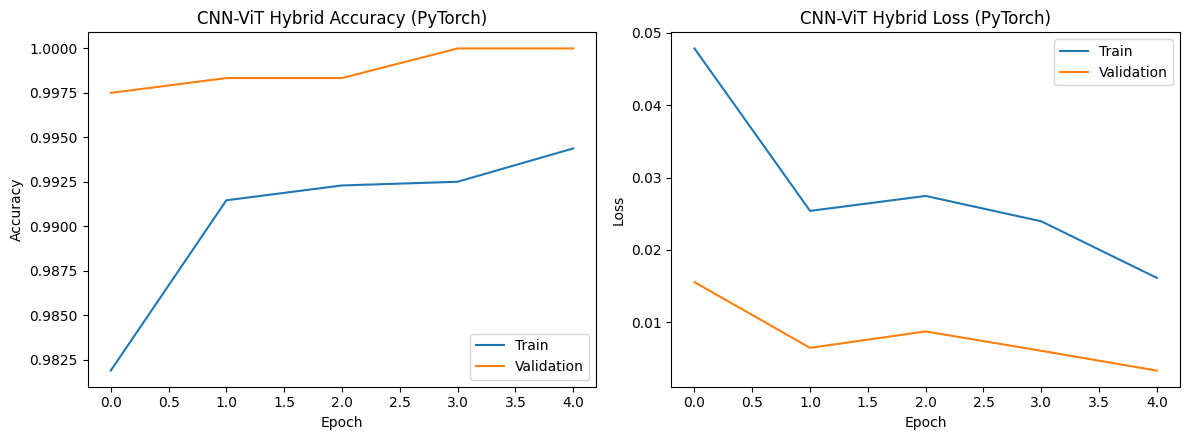

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history["train_acc"], label="Train")
axes[0].plot(history["val_acc"], label="Validation")
axes[0].set_title("CNN-ViT Hybrid Accuracy (PyTorch)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history["train_loss"], label="Train")
axes[1].plot(history["val_loss"], label="Validation")
axes[1].set_title("CNN-ViT Hybrid Loss (PyTorch)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Evaluation

In [9]:
cnn_vit_model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        logits = cnn_vit_model(images)
        preds = (torch.sigmoid(logits) >= 0.5).float().cpu().numpy().ravel()
        y_pred.extend(preds)
        y_true.extend(labels.numpy().ravel())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
print(f"F1-score : {f1_score(y_true, y_pred):.4f}")


Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


## 10. Save the hybrid model (needed for the final integration lab)

In [10]:
MODELS_DIR.mkdir(exist_ok=True)
torch.save(cnn_vit_model.state_dict(), MODELS_DIR / "pytorch_cnn_vit_hybrid.pt")
print(f"Saved model weights to {MODELS_DIR / 'pytorch_cnn_vit_hybrid.pt'}")


Saved model weights to pytorch_cnn_vit_hybrid.pt


## Summary

We built a PyTorch-based hybrid Convolutional Neural Network (CNN) and
Vision Transformer (ViT) for image classification: a frozen pretrained CNN
extracts local spatial features, which are tokenized, given positional
embeddings, and processed by stacked Transformer encoder blocks using
`nn.MultiheadAttention`, mirroring the Keras implementation from the
previous lab for a fair later comparison.
